In [1]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [2]:
import cv2

image = cv2.imread("../data/raw/test_image.jpg")

print(type(image))
print(image.shape)

<class 'numpy.ndarray'>
(1000, 727, 3)


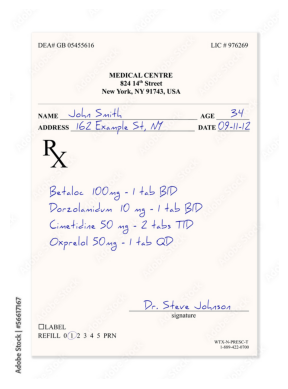

In [3]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [4]:
print(image[0, 0])

[255 255 255]


In [5]:
print(image[500, 300])

[241 250 254]


In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print(gray.shape)

(1000, 727)


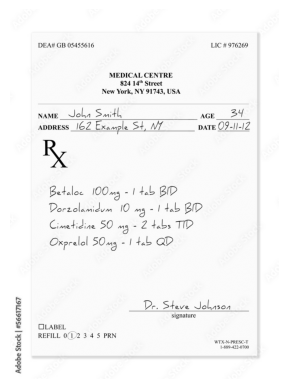

In [7]:
plt.imshow(gray, cmap="gray")
plt.axis("off");

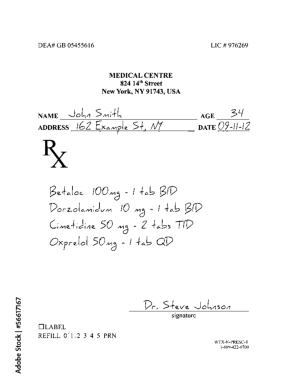

In [8]:
_, threshold = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

plt.imshow(threshold, cmap="gray")
plt.axis("off");

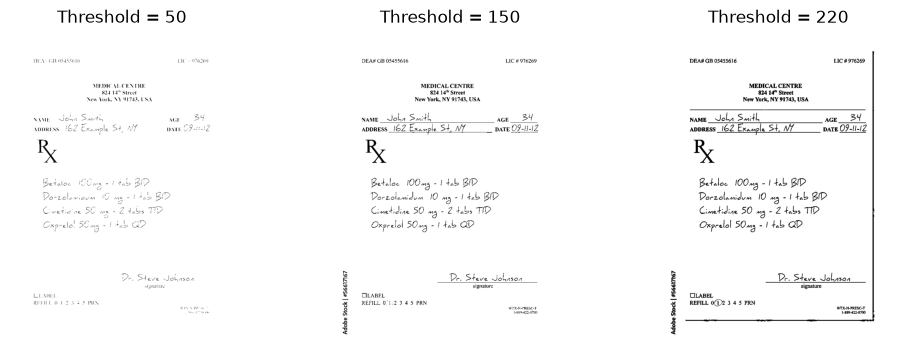

In [9]:
_, t50 = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
_, t150 = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
_, t220 = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(t50, cmap="gray")
plt.title("Threshold = 50")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(t150, cmap="gray")
plt.title("Threshold = 150")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(t220, cmap="gray")
plt.title("Threshold = 220")
plt.axis("off");

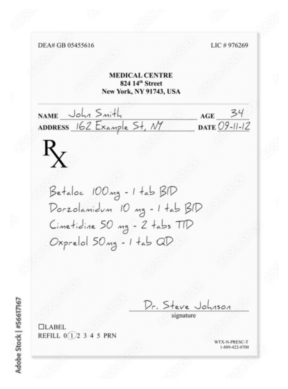

In [10]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.imshow(blur, cmap="gray")
plt.axis("off");

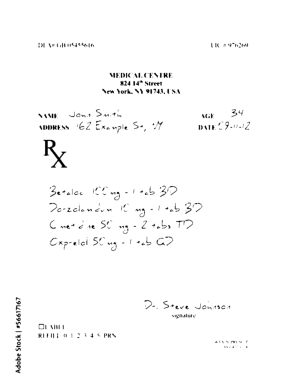

In [11]:
_, blur_threshold = cv2.threshold(
    blur, 150, 255, cv2.THRESH_BINARY
)

plt.imshow(blur_threshold, cmap="gray")
plt.axis("off");

In [12]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print(pytesseract.get_tesseract_version())

5.5.3.20260724


In [13]:
text = pytesseract.image_to_string(image)

print(text)

Adobe Stock | #56617167

DEA# GB 05455616 LIC # 976269

MEDICAL CENTRE
824 14" Street
New York, NY 91743, USA

naME_ Vola Smitl ace 24
Appress_16Z Example St M7 pate 09-I/-IZ

K

Betsloe 100mg - 1 tab BID
Dorzalanizze 10 mg: ! +.b BID
Crelvie SO mg - 2 +.b5 TID
Orprelel 50mg - | tab QD

De. Steve Jolson

signature

OLABEL ?
REFILL 0(12 3 4 5 PRN

WIX-N-PRESC-T
1-889-422-0700



In [14]:
text_gray = pytesseract.image_to_string(gray)

print(text_gray)

Adobe Stock | #56617167

DEA# GB 05455616 LIC # 976269

MEDICAL CENTRE
824 14" Street
New York, NY 91743, USA

name Vola Smitl ace 34
Appress_16Z Example St M7 pate 09-I/-IZ

K

Betaloc 100mg - | tab BID
Dorzolamidumn 10 mg! +.b BID
Gialthn SO mg - Z4+.bs TID
Oxprelol 50mg - | +.b QD

De. Steve Jolson

signature

OLABEL
REFILL 0(12 3 4 5 PRN

WIX-N-PRESC-T
1-889-422-0700



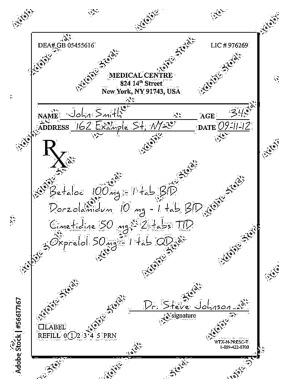

In [15]:
adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.imshow(adaptive, cmap="gray")
plt.axis("off");

In [16]:
text_adaptive = pytesseract.image_to_string(adaptive)

print(text_adaptive)

° & ‘MEDICAL CENTRE:
ee 824 14% Street: &
} New, York, NY91743, USA| GS
j = aye
NAME: vdobin Smit lt st AGE:

3
DEA# GB 05455616!
re Nee
3 &

ADDRESS 16Z Exznple St ES

OLABEL
REFILL 0(2)2: i
‘WERALPRESCT.
e889.22.070




In [17]:
cropped = image[y1:y2, x1:x2]

NameError: name 'y1' is not defined

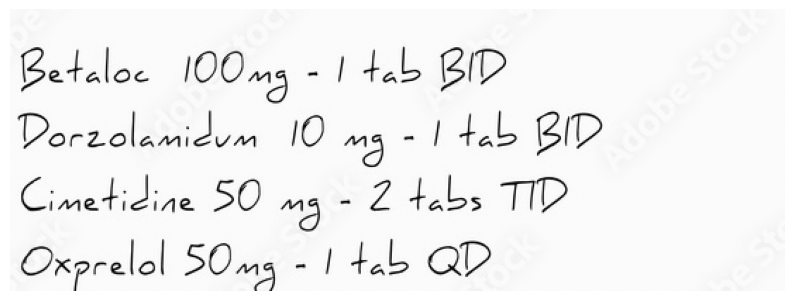

In [18]:
medicine_roi = gray[450:650, 100:650]

plt.figure(figsize=(10, 5))
plt.imshow(medicine_roi, cmap="gray")
plt.axis("off");

In [19]:
medicine_text = pytesseract.image_to_string(medicine_roi)

print(medicine_text)

Beteloe 100mg - | tab BID
Dorzolaridum 10 mg! +.b BID
Gialthn SO mg - Z4+.bs TID
Oxprelol SOmg - | tab QD



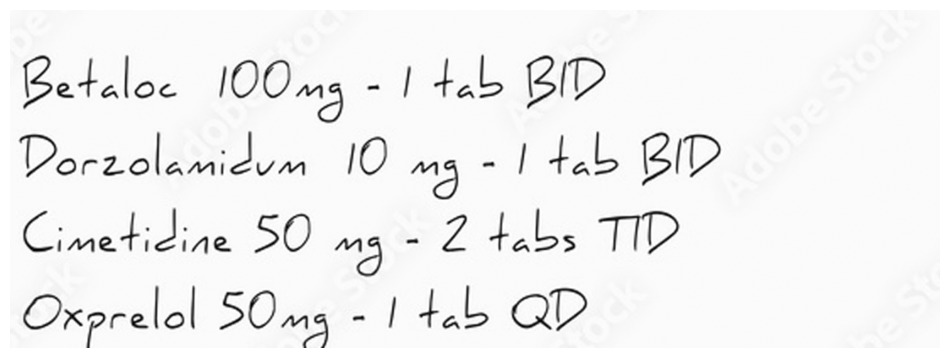

In [20]:
upscaled = cv2.resize(
    medicine_roi,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_CUBIC
)

plt.figure(figsize=(12, 6))
plt.imshow(upscaled, cmap="gray")
plt.axis("off");

In [21]:
upscaled_text = pytesseract.image_to_string(upscaled)

print(upscaled_text)

Betaloe [00 mg - | +.6 $ID
Vorzolavicun 10 mg - | +.b BID
Greene sc mg - Z Hales)
Oxprelol 50.ng - | tab QD

